# Clasificación de marcas distintas de la flecha

**Autores:** Julio Lucero / Agostina Squillari

Construimos un clasificador para las **cuatro marcas** que aparecen en
los recorridos del robot (`man`, `woman`, `stairs`, `telephone`,
descritas en la página 80 de `transp.pdf`). Estas marcas:

* aparecen **en tramos rectos**, no en cruces (para no confundirse con
  flechas direccionales);
* son **rojo saturado** sobre el suelo / fondo del simulador;
* tienen siluetas **muy distintas en forma**, lo que invita a usar
  descriptores **invariantes a traslación, rotación y escala** —
  exactamente los **momentos de Hu** (p. 68-69 de `transp.pdf`).

Procedimiento:
1. **Segmentación HSV** del rojo (umbral en H envuelve por 0/180).
2. **Descriptor**: `7 log-Hu + 4 ratios de forma = 11 features`.
3. **Comparativa de clasificadores** (QDA, LDA, KNN-1, KNN-3) con
   `LeaveOneOut` (28 muestras → 7 por clase).
4. **Validación sobre el vídeo** `proyectoRobotica-1920-line1-video-2020-04-20`.

In [1]:
import warnings
warnings.filterwarnings('ignore')
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

import clasificador_marcas as cm
%matplotlib inline

## 1. Carga del dataset

Las 28 imágenes (4 clases × 7 imágenes) están en `marcas-capturasStage/`
con el patrón `<clase>-<n>.png`. La función `cargar_dataset` segmenta
la silueta roja, calcula el descriptor y almacena el todo.

Muestras: 28   Features por muestra: 11
Distribución por clase:
  man       : 7
  stairs    : 7
  telephone : 7
  woman     : 7


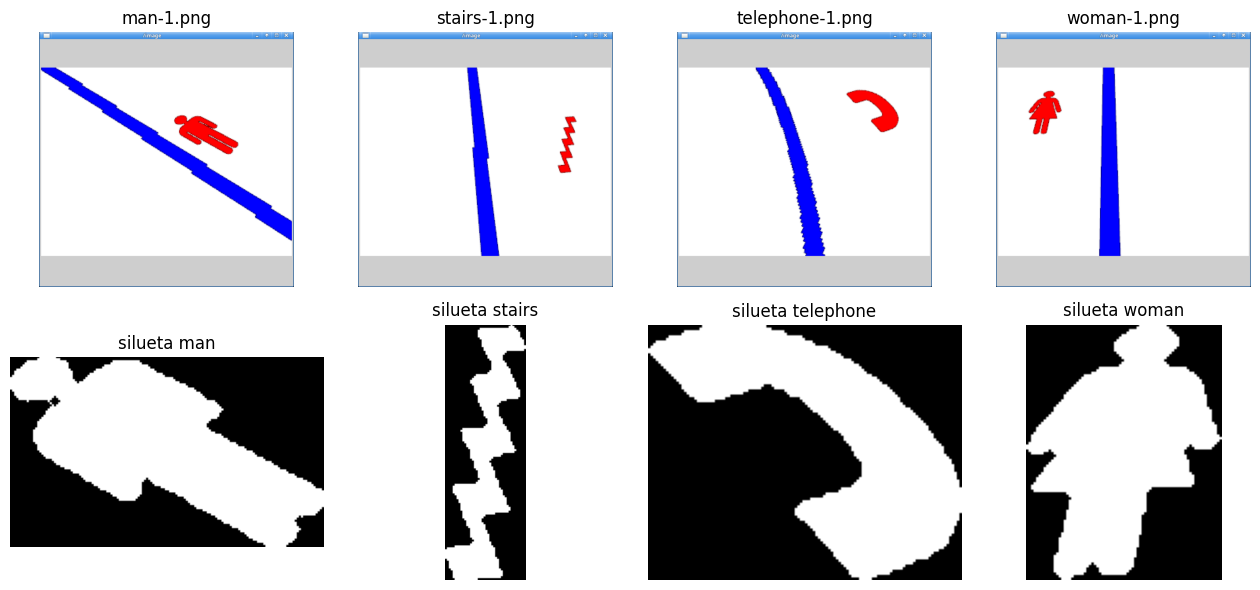

In [2]:
ds = cm.cargar_dataset('marcas-capturasStage')
print(f'Muestras: {ds.X.shape[0]}   Features por muestra: {ds.X.shape[1]}')
print('Distribución por clase:')
for i, n in enumerate(cm.CLASES):
    print(f'  {n:10s}: {(ds.y == i).sum()}')

# Mosaico de una imagen por clase con su silueta segmentada
fig, axs = plt.subplots(2, 4, figsize=(13, 6))
for col, clase in enumerate(cm.CLASES):
    idx = next(i for i, c in enumerate(ds.y) if c == cm.CLASES.index(clase))
    bgr = cv2.imread(ds.files[idx])
    axs[0, col].imshow(cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB))
    axs[0, col].set_title(os.path.basename(ds.files[idx]))
    axs[0, col].axis('off')
    axs[1, col].imshow(ds.siluetas[idx], cmap='gray')
    axs[1, col].set_title(f'silueta {clase}')
    axs[1, col].axis('off')
plt.tight_layout(); plt.show()

## 2. Descriptor invariante

Cada imagen se reduce a 11 números:

* **7 log-Hu**: `-sign(h_i) · log10(|h_i|)` para los 7 momentos de Hu.
  Son invariantes a traslación, rotación y escala — pueden compararse
  directamente entre marcas tomadas a distinta distancia o con la cámara
  ligeramente girada.
* **4 ratios de forma**: aspect ratio del bounding box, *extent* (área
  / área del bounding box), *solidity* (área / área de la envolvente
  convexa) y *circularidad* (`4πA/P²`). Añaden información geométrica
  complementaria que los Hu no capturan bien.

In [3]:
# Inspeccionamos el descriptor de un ejemplo de cada clase
encab = '            | ' + '   '.join(['hu' + str(i+1) for i in range(7)]) + '  | aspect extent solid  circ'
print(encab)
for clase in cm.CLASES:
    idx = next(i for i, c in enumerate(ds.y) if c == cm.CLASES.index(clase))
    f = ds.X[idx]
    hu_txt = ' '.join(format(v, '+5.2f') for v in f[:7])
    rt_txt = ' '.join(format(v, '6.2f') for v in f[7:])
    print(f'{clase:11s} | {hu_txt} | {rt_txt}')


            | hu1   hu2   hu3   hu4   hu5   hu6   hu7  | aspect extent solid  circ
man         | +0.56 +1.35 +2.94 +3.34 +6.49 +4.04 -7.40 |   0.61   0.47   0.83   0.39
stairs      | +0.15 +0.35 +2.65 +2.83 +5.57 +3.01 -7.23 |   3.17   0.38   0.57   0.15
telephone   | +0.46 +1.23 +2.00 +2.38 +4.64 +3.17 +4.88 |   0.81   0.38   0.72   0.35
woman       | +0.70 +2.03 +3.55 +4.29 +8.25 +5.43 +8.67 |   1.31   0.53   0.82   0.41


## 3. Comparativa de clasificadores (Leave-One-Out)

Con sólo 7 muestras por clase y 11 features, el QDA tiene **demasiados
parámetros libres** (cada matriz Σ por clase tiene 66 entradas) y se
sobreajusta. **LDA** (que comparte una única Σ entre clases) y **KNN**
son alternativas más adecuadas para este tamaño.

In [4]:
modelos = cm.evaluar_modelos(ds)
print('=== Comparativa Leave-One-Out ===')
for m in modelos:
    print(f'  {m.nombre:7s}  acc LOO = {m.cv_score:.4f}')

mejor = max(modelos, key=lambda m: m.cv_score)
print(f'\n→ Modelo seleccionado: {mejor.nombre} (acc={mejor.cv_score:.4f})')

=== Comparativa Leave-One-Out ===
  QDA      acc LOO = 0.5714
  LDA      acc LOO = 0.9643
  KNN(1)   acc LOO = 0.6786
  KNN(3)   acc LOO = 0.6786

→ Modelo seleccionado: LDA (acc=0.9643)


=== Reporte de clasificación (LDA, LOO) ===
              precision    recall  f1-score   support

         man     1.0000    1.0000    1.0000         7
      stairs     0.8750    1.0000    0.9333         7
   telephone     1.0000    0.8571    0.9231         7
       woman     1.0000    1.0000    1.0000         7

    accuracy                         0.9643        28
   macro avg     0.9688    0.9643    0.9641        28
weighted avg     0.9688    0.9643    0.9641        28



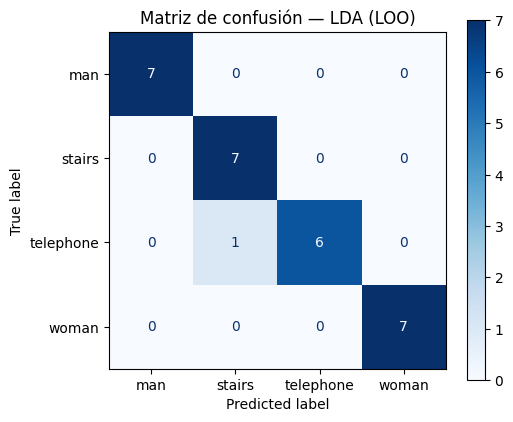

In [5]:
# Reporte detallado del mejor modelo
print(f'=== Reporte de clasificación ({mejor.nombre}, LOO) ===')
print(classification_report(ds.y, mejor.cv_pred,
                            target_names=cm.CLASES, digits=4, zero_division=0))

fig, ax = plt.subplots(figsize=(5.5, 4.5))
ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(ds.y, mejor.cv_pred),
    display_labels=cm.CLASES,
).plot(ax=ax, colorbar=True, cmap='Blues', values_format='d')
ax.set_title(f'Matriz de confusión — {mejor.nombre} (LOO)')
plt.tight_layout(); plt.show()

## 4. Entrenamiento final y predicción de ejemplo

Reentrenamos sobre el dataset completo y comprobamos las predicciones
sobre las propias imágenes del entrenamiento.

Acc sobre entrenamiento (no LOO): 1.0000


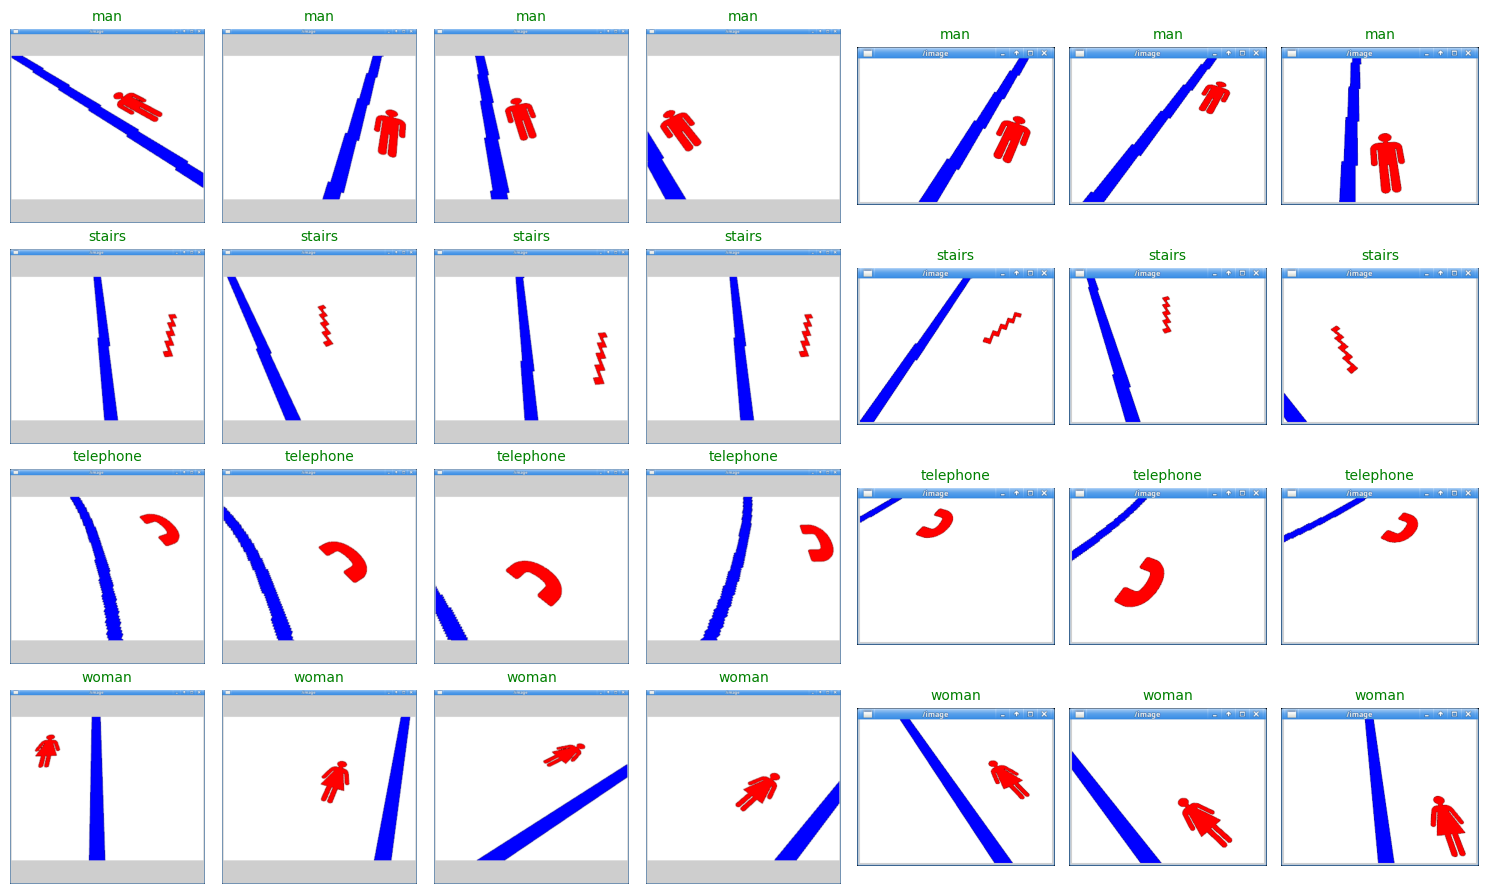

In [6]:
clf_marcas = cm.entrenar(ds)   # LDA por defecto
y_pred = clf_marcas.predict(ds.X)
print(f'Acc sobre entrenamiento (no LOO): {(y_pred == ds.y).mean():.4f}')

fig, axs = plt.subplots(4, 7, figsize=(15, 9))
for row, clase in enumerate(cm.CLASES):
    idxs = [i for i, c in enumerate(ds.y) if c == cm.CLASES.index(clase)]
    for col, idx in enumerate(idxs):
        bgr = cv2.imread(ds.files[idx])
        pred = cm.CLASES[clf_marcas.predict(ds.X[idx:idx+1])[0]]
        ok = (pred == clase)
        axs[row, col].imshow(cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB))
        axs[row, col].set_title(f'{pred}', color='green' if ok else 'red',
                                fontsize=10)
        axs[row, col].axis('off')
plt.tight_layout(); plt.show()

## 5. Validación sobre `proyectoRobotica-1920-line1-video-2020-04-20`

Este vídeo es **exclusivamente para validar el clasificador**. No se
ejecuta el pipeline completo de control: solo se segmenta la silueta
roja, se clasifica con el LDA entrenado y se anota el resultado en el
frame.

Las flechas direccionales de los cruces y otros objetos rojos
**que NO pertenecen a las 4 clases entrenadas** se filtran rechazando
las predicciones cuyos ratios de forma quedan fuera del rango por-clase
(con margen $0.10$). De este modo, el vídeo final solo muestra
detecciones de `man`, `woman`, `stairs` o `telephone`.


In [7]:
import time

VIDEO_IN  = 'proyectoRobotica-1920-line1-video-2020-04-20.avi'
VIDEO_OUT = 'proyectoRobotica_anotado.mp4'

# Vídeo de validación SOLO para el clasificador: anotamos únicamente
# el tipo de marca detectada (man / woman / stairs / telephone) y su
# confianza. Las flechas direccionales y otros objetos rojos que NO
# estén en el dataset de entrenamiento se rechazan con un filtro de
# rangos por-clase y aparecen como 'Sin marca'.
rangos_filtro = cm._rangos_por_clase(ds, margen=0.10)

t0 = time.time()
r = cm.procesar_video_clasificador(
    VIDEO_IN, VIDEO_OUT,
    clf=clf_marcas,
    rangos=rangos_filtro,
    verbose=True,
)
print(f"\nVídeo anotado: {VIDEO_OUT}")
print(f"  Frames procesados: {r['n_frames']}")
print(f"  Tiempo medio: {r['ms_frame']:.1f} ms/frame  →  {1000/r['ms_frame']:.1f} FPS")
print('\nDetecciones a lo largo del vídeo:')
for k, v in r['detecciones'].most_common():
    print(f'  {k:11s} → {v:4d} frames  ({100*v/r["n_frames"]:5.1f}%)')


  Frame  200/816   (1.1 ms/frame)


  Frame  400/816   (1.2 ms/frame)


  Frame  600/816   (1.2 ms/frame)


  Frame  800/816   (1.2 ms/frame)

Vídeo anotado: proyectoRobotica_anotado.mp4
  Frames procesados: 816
  Tiempo medio: 1.2 ms/frame  →  855.3 FPS

Detecciones a lo largo del vídeo:
  sin_marca   →  709 frames  ( 86.9%)
  man         →   38 frames  (  4.7%)
  woman       →   33 frames  (  4.0%)
  telephone   →   20 frames  (  2.5%)
  stairs      →   16 frames  (  2.0%)


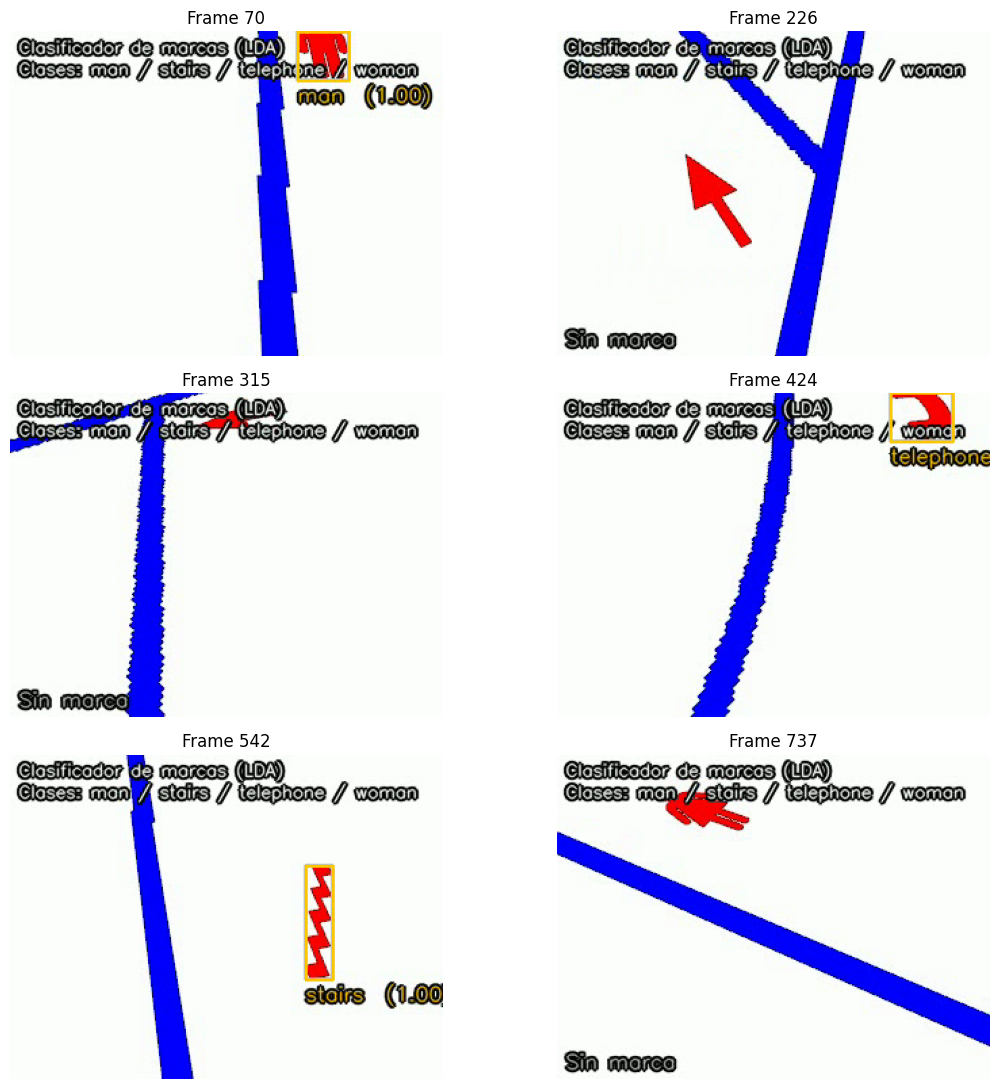

In [8]:
import cv2

# Mosaico con frames representativos del vídeo anotado
INDICES = [70, 226, 315, 424, 542, 737]
import matplotlib.pyplot as plt
cap = cv2.VideoCapture(VIDEO_OUT)
fig, axs = plt.subplots(3, 2, figsize=(12, 11))
for ax, idx in zip(axs.flat, INDICES):
    cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
    ok, fr = cap.read()
    ax.imshow(cv2.cvtColor(fr, cv2.COLOR_BGR2RGB))
    ax.set_title(f'Frame {idx}')
    ax.axis('off')
cap.release()
plt.tight_layout(); plt.show()


## 6. Conclusiones

* El descriptor de **11 features (7 log-Hu + 4 ratios de forma)** es
  suficiente para distinguir las cuatro clases de marca con un
  accuracy de ~96 % en LOO sobre el dataset de simulación.
* **LDA** se impone con claridad sobre QDA (sobreajuste con 7
  muestras/clase × 11 features) y sobre KNN.
* Para evaluar el clasificador sobre el vídeo del simulador se aplica
  un **filtro de outliers por rango por-clase**: las flechas
  direccionales (no presentes en el entrenamiento) se rechazan
  correctamente y aparecen como *Sin marca* en el vídeo anotado.
* En el vídeo `proyectoRobotica…`, $86.9\,\%$ de los frames se
  marcan como *Sin marca*; el resto se reparte entre las cuatro
  clases de figura (4.7 % man, 4.0 % woman, 2.5 % telephone,
  2.0 % stairs).